In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from v2_data_preparation import load_and_prepare_data

In [2]:
fp1 = '../outputs/predictions/SDH1_2000-2026_noAnchored_difRolling.csv'
fp2 = '../outputs/predictions/SDH2_2000-2026_noAnchored_difRolling.csv'

In [3]:
df1 = load_and_prepare_data(fp1)
df2 = load_and_prepare_data(fp2)

In [4]:
# 1. Preparar datos
df1["year"] = df1.index.year
df1["day_of_year"] = df1.index.dayofyear

df2["year"] = df2.index.year
df2["day_of_year"] = df2.index.dayofyear


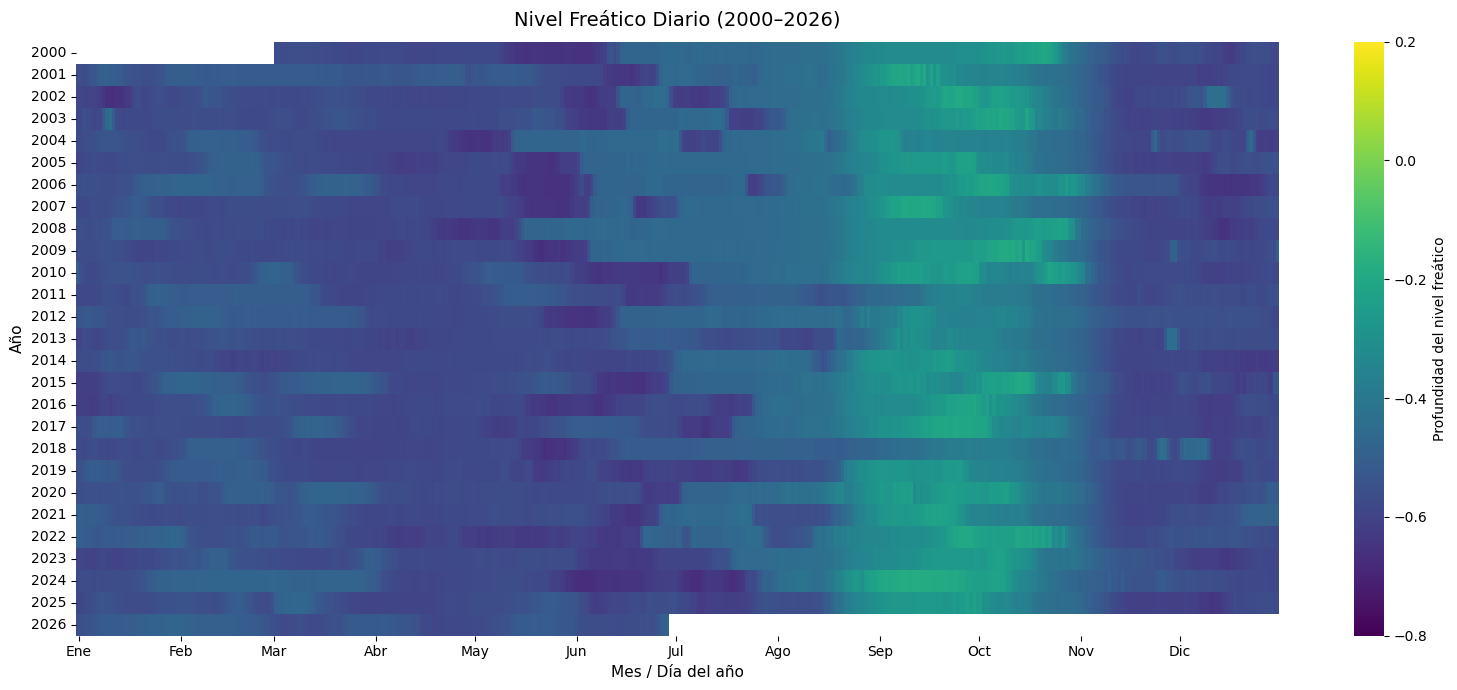

In [5]:
# Filtrar el día bisiesto 366 para mantener la cuadrícula fija de 1 a 365
df1_filtered = df1[df1["day_of_year"] <= 365]

# 2. Pivotar la tabla (Años en filas, Días del año en columnas)
heatmap_data = df1_filtered.pivot(
    index="year", columns="day_of_year", values="predicted"
)

# Garantizar que todos los años (2000 a 2026) y días (1 a 365) existan en la matriz
years_range = list(range(2000, 2027))
days_range = list(range(1, 366))
heatmap_data = heatmap_data.reindex(index=years_range, columns=days_range)

# 3. Graficar
fig, ax = plt.subplots(figsize=(16, 7))

# 'viridis', 'mako' o 'Blues_r' funcionan muy bien para niveles freáticos
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    cbar_kws={"label": "Profundidad del nivel freático"},
    ax=ax,
    vmin=-0.8,
    vmax=0.2
)

# 4. Ajustar marcas y etiquetas del eje X por meses
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

ax.set_xticks(month_starts)
ax.set_xticklabels(month_names, rotation=0)

ax.set_title("Nivel Freático Diario (2000–2026)", fontsize=14, pad=12)
ax.set_xlabel("Mes / Día del año", fontsize=11)
ax.set_ylabel("Año", fontsize=11)

plt.tight_layout()
plt.show()


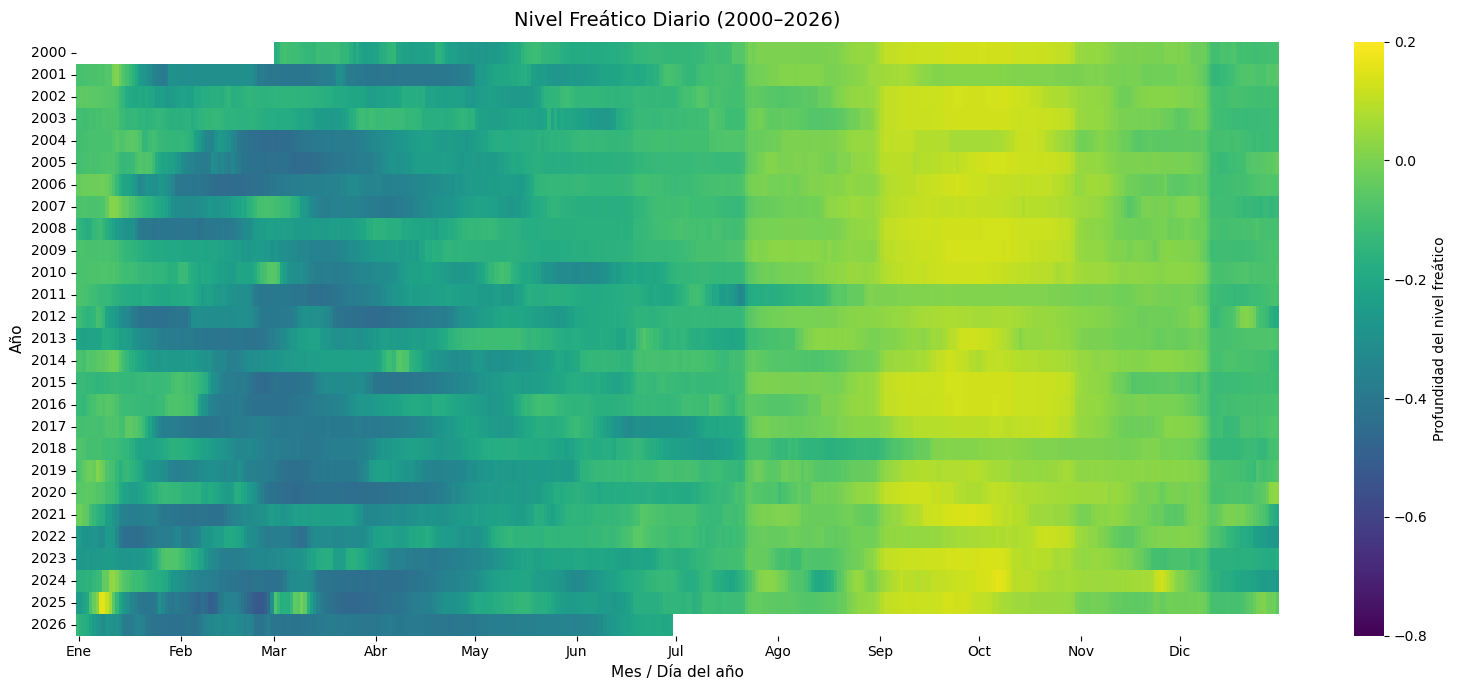

In [6]:
# Filtrar el día bisiesto 366 para mantener la cuadrícula fija de 1 a 365
df2_filtered = df2[df2["day_of_year"] <= 365]

# 2. Pivotar la tabla (Años en filas, Días del año en columnas)
heatmap_data = df2_filtered.pivot(
    index="year", columns="day_of_year", values="predicted"
)

# Garantizar que todos los años (2000 a 2026) y días (1 a 365) existan en la matriz
years_range = list(range(2000, 2027))
days_range = list(range(1, 366))
heatmap_data = heatmap_data.reindex(index=years_range, columns=days_range)

# 3. Graficar
fig, ax = plt.subplots(figsize=(16, 7))

# 'viridis', 'mako' o 'Blues_r' funcionan muy bien para niveles freáticos
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    cbar_kws={"label": "Profundidad del nivel freático"},
    ax=ax,
    vmin=-0.8,
    vmax=0.2
)

# 4. Ajustar marcas y etiquetas del eje X por meses
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic",
]

ax.set_xticks(month_starts)
ax.set_xticklabels(month_names, rotation=0)

ax.set_title("Nivel Freático Diario (2000–2026)", fontsize=14, pad=12)
ax.set_xlabel("Mes / Día del año", fontsize=11)
ax.set_ylabel("Año", fontsize=11)

plt.tight_layout()
plt.show()
